In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torchvision import datasets
from torch.utils.data import random_split
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch


First we split our dataset. We're loading the dataset using `datasets.MNIST`. This method automatically splits the dataset into train and "non-train" or test datasets. So we directly split into train and test data with this method and then we take 10,000 observations from the train dataset to create the validation dataset.

In [ ]:

full_train = datasets.MNIST(root="data", train=True, download=True, transform=ToTensor())
test_data = datasets.MNIST(root="data", train=False, download=True, transform=ToTensor())

training_data, validation_data = random_split(
    full_train,
    [50_000, 10_000],
    generator=torch.Generator().manual_seed(42)
)

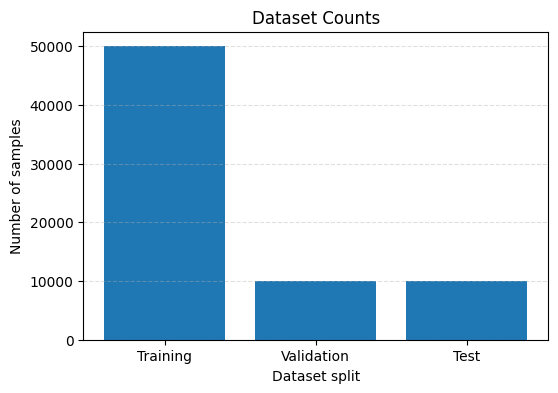

In [21]:
plt.figure(figsize=(6, 4))
dataset_counts = [len(training_data), len(validation_data), len(test_data)]
dataset_labels = ["Training", "Validation", "Test"]
plt.bar(dataset_labels, dataset_counts)
plt.title("Dataset Counts")
plt.ylabel("Number of samples")
plt.xlabel("Dataset split")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

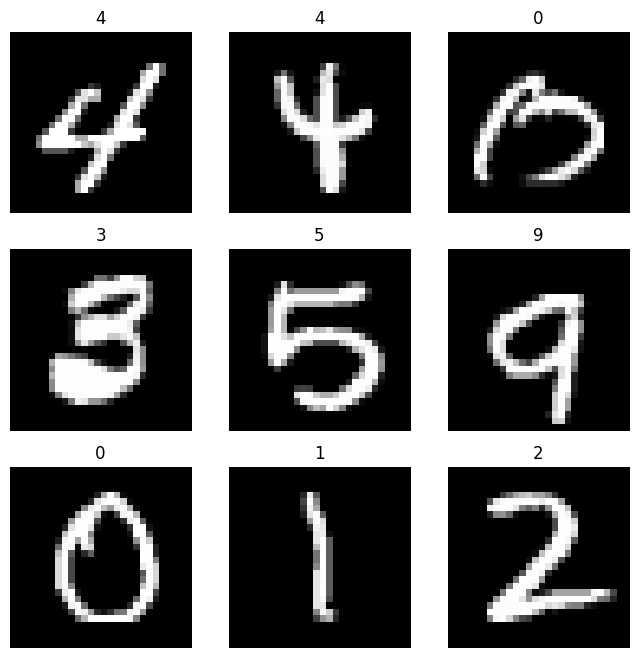

In [17]:
labels_map = {
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6",
    7: "7",
    8: "8",
    9: "9",
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [ ]:
import torch.nn as nn

class FeedForwardNN(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self, x):
        return x

In [ ]:
model = model()
x = torch.rand(1, 28, 28)
output = model(x)

In [ ]:
experiments = [
    {
        "hidden":     [128, 64],
        "optimizer":  "adam",
        "lr":         0.001,
        "batch_size": 32,
        "epochs":     5,
    },
    {
        "hidden":     [256, 128, 64],
        "optimizer":  "adam",
        "lr":         0.001,
        "batch_size": 32,
        "epochs":     5,
    },
    {
        "hidden":     [128, 64],
        "optimizer":  "sgd",
        "lr":         0.01,
        "batch_size": 128,
        "epochs":     10,
    },
]

# ── Model class that accepts a config ─────────────────────────────────────────
class FlexibleNN(nn.Module):
    def __init__(self, hidden_sizes):
        super().__init__()
        layers = [nn.Flatten(), nn.Linear(784, hidden_sizes[0]), nn.ReLU()]
        for i in range(1, len(hidden_sizes)):
            layers += [nn.Linear(hidden_sizes[i-1], hidden_sizes[i]), nn.ReLU()]
        layers += [nn.Linear(hidden_sizes[-1], 10)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# ── Run all experiments ────────────────────────────────────────────────────────
for cfg in experiments:
    # DataLoader uses batch_size from config
    train_loader = DataLoader(train_data, batch_size=cfg["batch_size"], shuffle=True)

    # Model uses hidden sizes from config
    model = FlexibleNN(cfg["hidden"]).to(device)

    # Optimizer uses optimizer type and lr from config
    if cfg["optimizer"] == "adam":
        optimizer = optim.Adam(model.parameters(), lr=cfg["lr"])
    elif cfg["optimizer"] == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=cfg["lr"])

    # Training loop uses epochs from config
    for epoch in range(cfg["epochs"]):
        ...